In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [75]:
# 데이터 수집 및 로드
df = pd.read_csv('data/train.csv')
df.head()

,customer_id,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned
0,1,32,Montana,Free,Yearly,2,Paypal,Medium,-1606,22.391362,105.394516,0.176873,169,109,18,32,52,35,46,0
1,2,64,New Jersey,Free,Monthly,3,Paypal,Low,-2897,29.294210,52.501115,0.981811,55,163,44,33,12,25,37,1
2,3,51,Washington,Premium,Yearly,2,Credit Card,High,-348,15.400312,24.703696,0.048411,244,117,20,129,50,28,38,0
3,4,63,California,Family,Yearly,4,Apple Pay,Medium,-2894,22.842084,83.595480,0.035691,442,252,47,120,55,17,24,0
4,5,54,Washington,Family,Monthly,3,Paypal,High,-92,23.151163,52.578266,0.039738,243,230,41,66,40,32,47,0


In [76]:
# 데이터 구조 및 속성(변수 이해)
print(df.shape)
print(df.dtypes)
print()

# 각 변수별 결측치 확인
df.info()

(125000, 20)
customer_id                     int64
age                             int64
location                          str
subscription_type                 str
payment_plan                      str
num_subscription_pauses         int64
payment_method                    str
customer_service_inquiries        str
signup_date                     int64
weekly_hours                  float64
average_session_length        float64
song_skip_rate                float64
weekly_songs_played             int64
weekly_unique_songs             int64
num_favorite_artists            int64
num_platform_friends            int64
num_playlists_created           int64
num_shared_playlists            int64
notifications_clicked           int64
churned                         int64
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   ----

In [77]:
# 데이터 요약 및 통계 확인
# df.describe() # 수치형 + 날짜형

# 중복 데이터 확인
df.describe(include='str') # 문자형

,location,subscription_type,payment_plan,payment_method,customer_service_inquiries
count,125000,125000,125000,125000,125000
unique,19,4,2,4,3
top,Georgia,Premium,Monthly,Debit Card,Low
freq,6705,31354,62562,31292,41873


In [78]:
# 시각화 기본 설정
plt.rcParams['figure.figsize'] = (8, 5)

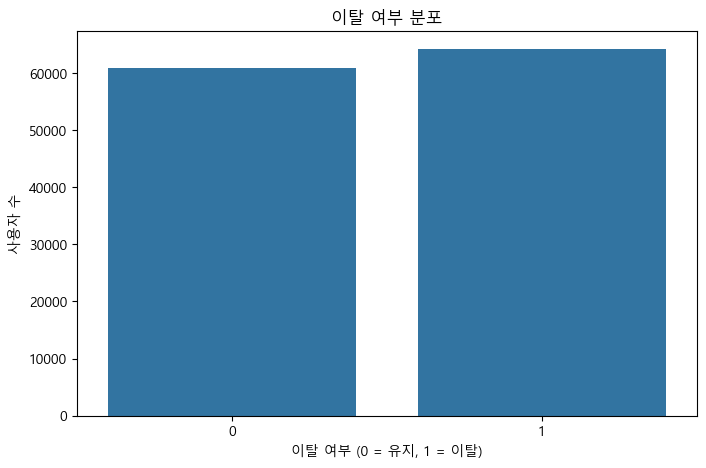

In [88]:
# ================================
# 2. 이탈 여부 분포 확인
# ================================
plt.figure()
sns.countplot(data=df, x='churned')
plt.title('이탈 여부 분포')
plt.xlabel('이탈 여부 (0 = 유지, 1 = 이탈)')
plt.ylabel('사용자 수')
plt.show()

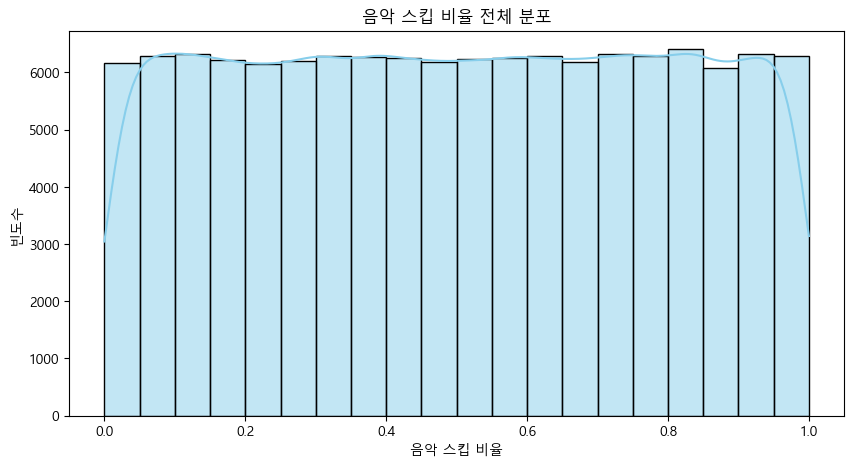

In [89]:
# ================================
# 3. 음악 스킵 비율 전체 분포 확인
# ================================
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='song_skip_rate', bins=20, kde=True, color='skyblue')
plt.title('음악 스킵 비율 전체 분포')
plt.xlabel('음악 스킵 비율')
plt.ylabel('빈도수')
plt.show()

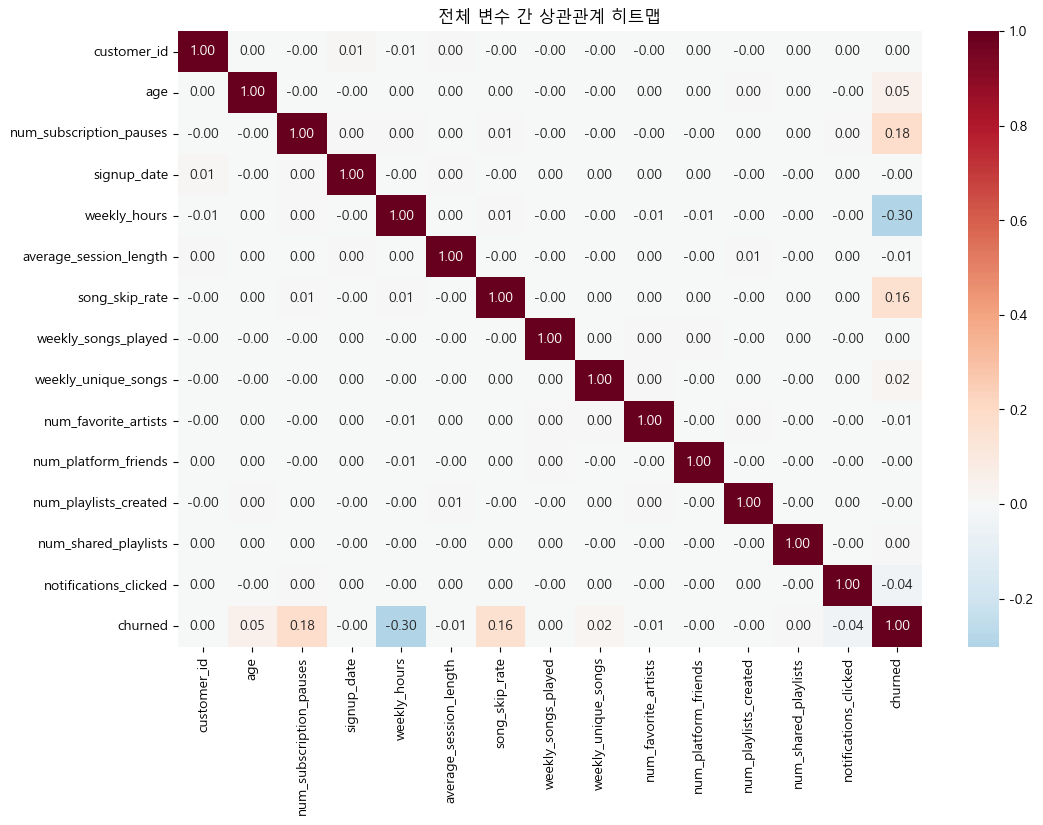

In [90]:
# ================================
# 4. 전체 수치형 변수 간 상관관계 히트맵
# ================================
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0
)
plt.title('전체 변수 간 상관관계 히트맵')
plt.show()

In [91]:
# ================================
# 5. 이탈 여부별 음악 스킵 비율 평균 및 상관계수 확인
# ================================
print("\n[이탈 여부별 음악 스킵 비율 평균]")
print(df.groupby('churned')['song_skip_rate'].mean())

correlation = df[['song_skip_rate', 'churned']].corr().iloc[0, 1]
print(f"\n노래 스킵 비율과 이탈 여부 간의 상관계수: {correlation:.4f}")


[이탈 여부별 음악 스킵 비율 평균]
churned
0    0.453300
1    0.545826
Name: song_skip_rate, dtype: float64

노래 스킵 비율과 이탈 여부 간의 상관계수: 0.1602


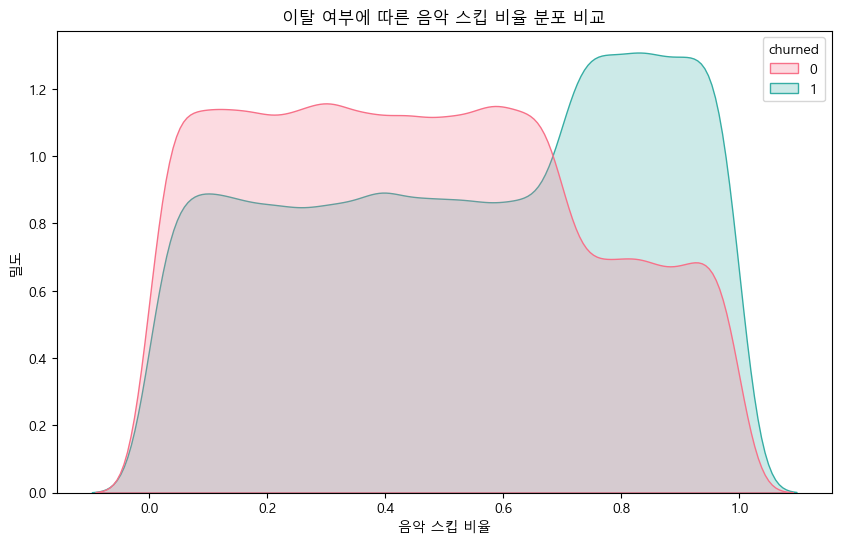

In [92]:
# ================================
# 6. 이탈 여부에 따른 음악 스킵 비율 분포 비교 (KDE Plot)
# ================================
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df,
    x='song_skip_rate',
    hue='churned',
    fill=True,
    common_norm=False,
    palette='husl'
)
plt.title('이탈 여부에 따른 음악 스킵 비율 분포 비교')
plt.xlabel('음악 스킵 비율')
plt.ylabel('밀도')
plt.show()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_14468\2120903889.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


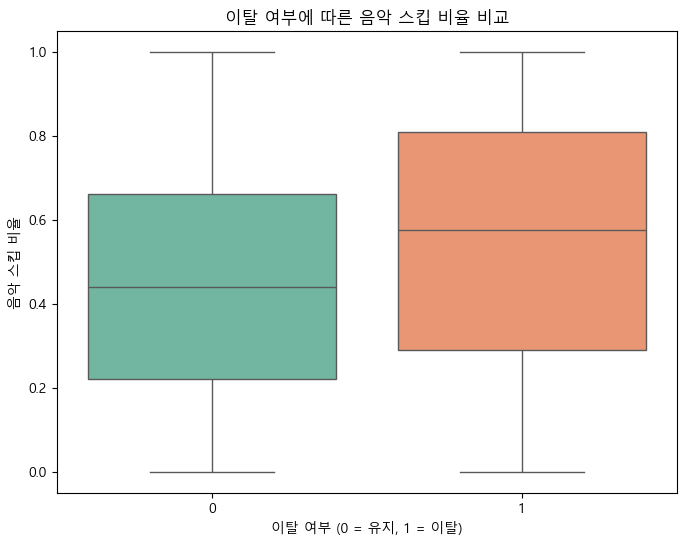

In [93]:
# ================================
# 7. 이탈 여부에 따른 음악 스킵 비율 비교 (Boxplot)
# ================================
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x='churned',
    y='song_skip_rate',
    palette='Set2'
)
plt.title('이탈 여부에 따른 음악 스킵 비율 비교')
plt.xlabel('이탈 여부 (0 = 유지, 1 = 이탈)')
plt.ylabel('음악 스킵 비율')
plt.show()


C:\Users\Playdata\AppData\Local\Temp\ipykernel_14468\963343428.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


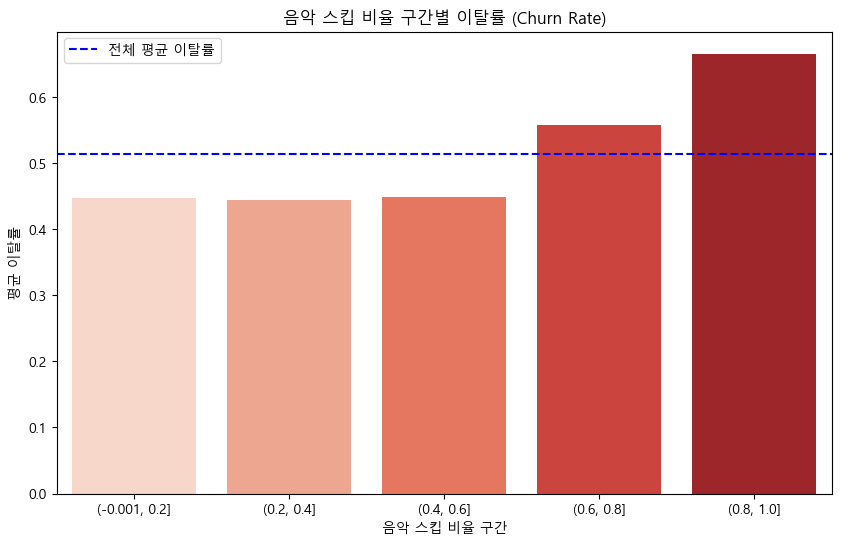

In [94]:
# ================================
# 8. 스킵 비율 구간별 이탈률 분석
# ================================
df['skip_group'] = pd.cut(
    df['song_skip_rate'],
    bins=np.arange(0, 1.1, 0.2),
    include_lowest=True
)

skip_churn_rate = (
    df.groupby('skip_group', observed=False)['churned']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=skip_churn_rate,
    x='skip_group',
    y='churned',
    palette='Reds'
)
plt.axhline(
    df['churned'].mean(),
    color='blue',
    linestyle='--',
    label='전체 평균 이탈률'
)
plt.title('음악 스킵 비율 구간별 이탈률 (Churn Rate)')
plt.xlabel('음악 스킵 비율 구간')
plt.ylabel('평균 이탈률')
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [95]:
# ================================
# 9. 구간별 이탈률 수치 확인
# ================================
print("\n[음악 스킵 비율 구간별 이탈률]")
print(skip_churn_rate)


[음악 스킵 비율 구간별 이탈률]
      skip_group   churned
0  (-0.001, 0.2]  0.447925
1     (0.2, 0.4]  0.444302
2     (0.4, 0.6]  0.449526
3     (0.6, 0.8]  0.557836
4     (0.8, 1.0]  0.666109
